# D3 — UCI Adult Dataset
## P26: Algorithmic Fairness in Credit Scoring
**Ibrahim Silima Mnemba | IIT Madras Zanzibar | June 2026**

### D3 Tasks
1. Compare results with at least 2 existing studies
2. Improvement: Combined Pruning + Quantization (order effect study)

**Reference:** Han et al. (ICLR 2016) Deep Compression — extended to fairness analysis.

## 0. Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.utils.prune as prune

SEEDS = [42, 0, 1, 2, 3]
np.random.seed(42); torch.manual_seed(42)
print('All imports done')

All imports done


## 1. Load & Preprocess UCI Adult

In [2]:
col_names = ['age','workclass','fnlwgt','education','education_num',
             'marital_status','occupation','relationship','race','sex',
             'capital_gain','capital_loss','hours_per_week','native_country','income']
url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
url_test  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'
train_df = pd.read_csv(url_train, header=None, sep=',', na_values='?', skipinitialspace=True, names=col_names)
test_df  = pd.read_csv(url_test,  header=None, sep=',', na_values='?', skipinitialspace=True, names=col_names, skiprows=1)
test_df['income'] = test_df['income'].str.replace('.','',regex=False)
df = pd.concat([train_df, test_df], ignore_index=True)
for col in ['workclass','occupation','native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

gender = (df['sex'].str.strip() == 'Male').astype(int).values
race   = (df['race'].str.strip() == 'White').astype(int).values
df['target'] = (df['income'].str.strip().str.replace('.','',regex=False) == '>50K').astype(int)
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
drop_cols = ['target','income'] if 'income' in df.columns else ['target']
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].values.astype(float); y = df['target'].values.astype(int)
scaler = StandardScaler(); X_scaled = scaler.fit_transform(X)
idx_all = np.arange(len(y))
_, idx_te42 = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)
print(f'Shape: {X_scaled.shape} | Classes: Low={sum(y==0):,}, High={sum(y==1):,}')

Shape: (48842, 14) | Classes: Low=37,155, High=11,687


## 2. Helper Functions

In [3]:
def build_mlp(inp):
    return nn.Sequential(
        nn.Linear(inp,64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64,32),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32,1)
    )

def train_mlp_early(Xtr, ytr, Xte, yte, seed, max_epochs=200, bs=32, lr=1e-3, patience=10):
    torch.manual_seed(seed); np.random.seed(seed)
    pw   = torch.tensor([(ytr==0).sum()/max((ytr==1).sum(),1)], dtype=torch.float32)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    m    = build_mlp(Xtr.shape[1])
    opt  = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    dl   = DataLoader(TensorDataset(torch.FloatTensor(Xtr),
                      torch.FloatTensor(ytr.astype(np.float32))),
                      batch_size=bs, shuffle=True, drop_last=True)
    best_loss=float('inf'); no_imp=0; best_w=None
    for epoch in range(max_epochs):
        m.train(); el=0
        for xb,yb in dl:
            opt.zero_grad()
            out=m(xb).squeeze()
            if out.dim()==0: out=out.unsqueeze(0)
            loss=crit(out,yb); loss.backward(); opt.step(); el+=loss.item()
        avg=el/len(dl)
        if avg < best_loss-1e-4: best_loss=avg; no_imp=0; best_w=copy.deepcopy(m.state_dict())
        else: no_imp+=1
        if no_imp>=patience: break
    if best_w: m.load_state_dict(best_w)
    m.eval()
    with torch.no_grad():
        pr=torch.sigmoid(m(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr=(pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), m, pd_arr, pr

def eval_mlp(model, Xte, yte):
    model.eval()
    with torch.no_grad():
        pr=torch.sigmoid(model(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr=(pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), pd_arr, pr

def apply_pruning(model, sparsity):
    m = copy.deepcopy(model)
    for _, module in m.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=sparsity)
            prune.remove(module, 'weight')
    return m

def apply_quantization(model):
    try:
        return torch.quantization.quantize_dynamic(
            copy.deepcopy(model).cpu(), {nn.Linear}, dtype=torch.qint8)
    except:
        return copy.deepcopy(model)

def fairness_manual(y_true, y_pred, sensitive, privileged=1):
    priv=(sensitive==privileged); unpriv=~priv
    dpd=abs(y_pred[priv].mean()-y_pred[unpriv].mean())
    def tpr(mask):
        tp=((y_pred[mask]==1)&(y_true[mask]==1)).sum()
        fn=((y_pred[mask]==0)&(y_true[mask]==1)).sum()
        return tp/(tp+fn+1e-9)
    eod=abs(tpr(priv)-tpr(unpriv))
    return round(float(dpd),4), round(float(eod),4)

print('Helper functions defined')

Helper functions defined


## 3. Train Base MLP (5 seeds, early stopping)

In [4]:
mlp_res = {'accuracy':[],'f1':[],'auc':[]}
mlp_models, mlp_splits = [], []
print('Training MLP across 5 seeds...')
for seed in SEEDS:
    print(f'  Seed {seed}...')
    Xtr,Xte,ytr,yte = train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    acc,f1,auc,mdl,pds,prs = train_mlp_early(Xtr,ytr.astype(np.float32),Xte,yte,seed)
    mlp_res['accuracy'].append(acc); mlp_res['f1'].append(f1); mlp_res['auc'].append(auc)
    mlp_models.append(copy.deepcopy(mdl)); mlp_splits.append((Xtr,Xte,ytr,yte,pds,prs))
print(f'Base MLP  Acc:{np.mean(mlp_res["accuracy"]):.4f}+/-{np.std(mlp_res["accuracy"]):.4f}')

Training MLP across 5 seeds...
  Seed 42...
  Seed 0...
  Seed 1...
  Seed 2...
  Seed 3...
Base MLP  Acc:0.8003+/-0.0055


## 4. D3 Improvement — Combined Pruning + Quantization (Order Effect)

**Research question:** Does the ORDER of compression affect accuracy AND fairness on UCI Adult?

**5 scenarios:**
- Base MLP
- Prune 70% only
- Quantize only
- **Pipeline A: Prune 70% then Quantize** (new)
- **Pipeline B: Quantize then Prune 70%** (new)

In [5]:
SPARSITY = 0.7

pipeline_results = {
    'Base MLP':     {'accuracy':[],'f1':[],'auc':[]},
    'Prune 70%':    {'accuracy':[],'f1':[],'auc':[]},
    'Quant only':   {'accuracy':[],'f1':[],'auc':[]},
    'Prune->Quant': {'accuracy':[],'f1':[],'auc':[]},
    'Quant->Prune': {'accuracy':[],'f1':[],'auc':[]},
}

for i, seed in enumerate(SEEDS):
    _, Xte, _, yte, _, _ = mlp_splits[i]
    bm = mlp_models[i]

    acc,f1,auc,_,_ = eval_mlp(bm, Xte, yte)
    pipeline_results['Base MLP']['accuracy'].append(acc)
    pipeline_results['Base MLP']['f1'].append(f1)
    pipeline_results['Base MLP']['auc'].append(auc)

    acc,f1,auc,_,_ = eval_mlp(apply_pruning(bm, SPARSITY), Xte, yte)
    pipeline_results['Prune 70%']['accuracy'].append(acc)
    pipeline_results['Prune 70%']['f1'].append(f1)
    pipeline_results['Prune 70%']['auc'].append(auc)

    acc,f1,auc,_,_ = eval_mlp(apply_quantization(bm), Xte, yte)
    pipeline_results['Quant only']['accuracy'].append(acc)
    pipeline_results['Quant only']['f1'].append(f1)
    pipeline_results['Quant only']['auc'].append(auc)

    acc,f1,auc,_,_ = eval_mlp(apply_quantization(apply_pruning(bm, SPARSITY)), Xte, yte)
    pipeline_results['Prune->Quant']['accuracy'].append(acc)
    pipeline_results['Prune->Quant']['f1'].append(f1)
    pipeline_results['Prune->Quant']['auc'].append(auc)

    acc,f1,auc,_,_ = eval_mlp(apply_pruning(apply_quantization(bm), SPARSITY), Xte, yte)
    pipeline_results['Quant->Prune']['accuracy'].append(acc)
    pipeline_results['Quant->Prune']['f1'].append(f1)
    pipeline_results['Quant->Prune']['auc'].append(auc)

print('=== PIPELINE RESULTS ===')
print(f'{"Scenario":<18} {"Accuracy":>18} {"F1":>16} {"AUC":>16}')
print('-'*70)
for name, r in pipeline_results.items():
    print(f'{name:<18} {np.mean(r["accuracy"]):.4f}+/-{np.std(r["accuracy"]):.4f}   {np.mean(r["f1"]):.4f}+/-{np.std(r["f1"]):.4f}   {np.mean(r["auc"]):.4f}+/-{np.std(r["auc"]):.4f}')

=== PIPELINE RESULTS ===
Scenario                     Accuracy               F1              AUC
----------------------------------------------------------------------
Base MLP           0.8003+/-0.0055   0.6767+/-0.0051   0.9098+/-0.0027
Prune 70%          0.8182+/-0.0480   0.6369+/-0.0182   0.8965+/-0.0050
Quant only         0.7987+/-0.0056   0.6759+/-0.0048   0.9098+/-0.0027
Prune->Quant       0.8153+/-0.0545   0.6321+/-0.0170   0.8943+/-0.0048
Quant->Prune       0.7987+/-0.0056   0.6759+/-0.0048   0.9098+/-0.0027


## 5. Fairness — All 5 Pipelines

In [6]:
Xte_f = X_scaled[idx_te42]; yte_f = y[idx_te42]
g_f   = gender[idx_te42];   r_f   = race[idx_te42]
bm    = mlp_models[0]

scenarios = {
    'Base MLP':     eval_mlp(bm, Xte_f, yte_f)[3:],
    'Prune 70%':    eval_mlp(apply_pruning(bm, SPARSITY), Xte_f, yte_f)[3:],
    'Quant only':   eval_mlp(apply_quantization(bm), Xte_f, yte_f)[3:],
    'Prune->Quant': eval_mlp(apply_quantization(apply_pruning(bm, SPARSITY)), Xte_f, yte_f)[3:],
    'Quant->Prune': eval_mlp(apply_pruning(apply_quantization(bm), SPARSITY), Xte_f, yte_f)[3:],
}

print('=== GENDER FAIRNESS ===')
print(f'{"Scenario":<18} {"DPD":>8} {"EOD":>8}'); print('-'*36)
gf_res = {}
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte_f, pds, g_f)
    gf_res[name]={'dpd':dpd,'eod':eod}; print(f'{name:<18} {dpd:>8.4f} {eod:>8.4f}')

print('\n=== RACE FAIRNESS ===')
print(f'{"Scenario":<18} {"DPD":>8} {"EOD":>8}'); print('-'*36)
rf_res = {}
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte_f, pds, r_f)
    rf_res[name]={'dpd':dpd,'eod':eod}; print(f'{name:<18} {dpd:>8.4f} {eod:>8.4f}')
print('\nLower = fairer')

=== GENDER FAIRNESS ===
Scenario                DPD      EOD
------------------------------------
Base MLP             0.3209   0.1415
Prune 70%            0.1863   0.0620
Quant only           0.3203   0.1352
Prune->Quant         0.1383   0.0091
Quant->Prune         0.3203   0.1352

=== RACE FAIRNESS ===
Scenario                DPD      EOD
------------------------------------
Base MLP             0.1564   0.0869
Prune 70%            0.0826   0.0721
Quant only           0.1512   0.0790
Prune->Quant         0.0766   0.0715
Quant->Prune         0.1512   0.0790

Lower = fairer


## 6. Visualization

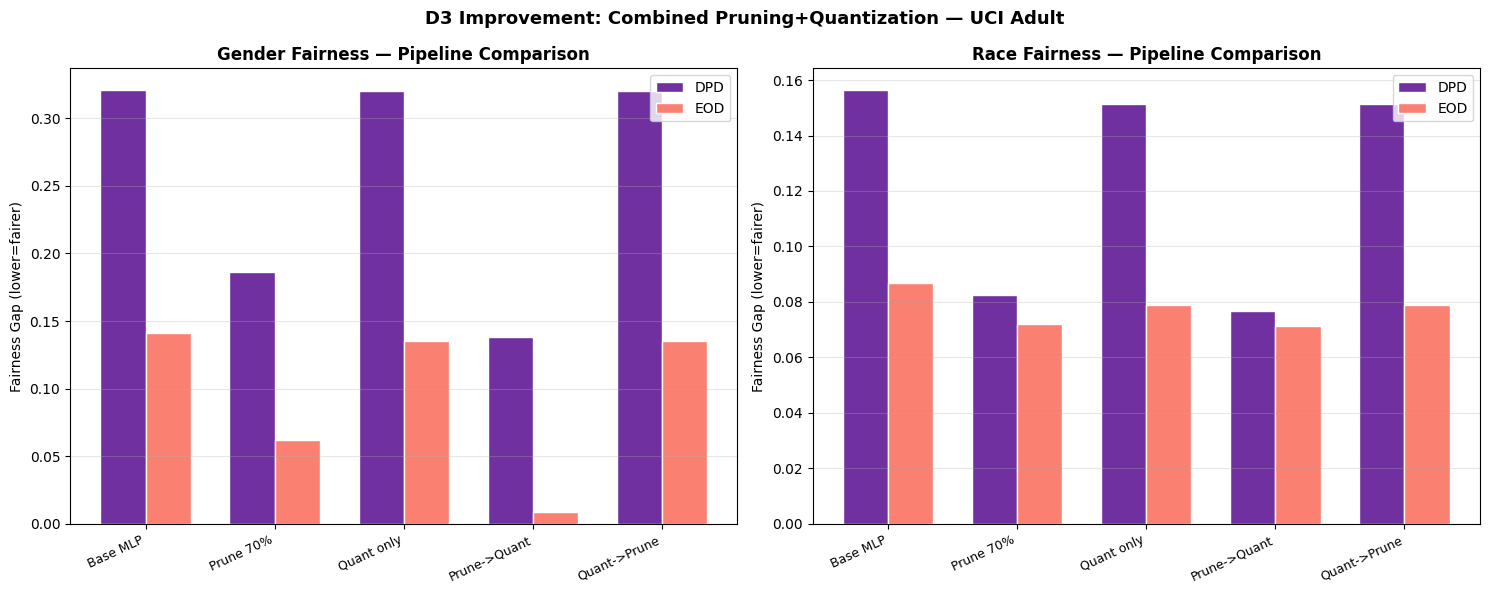

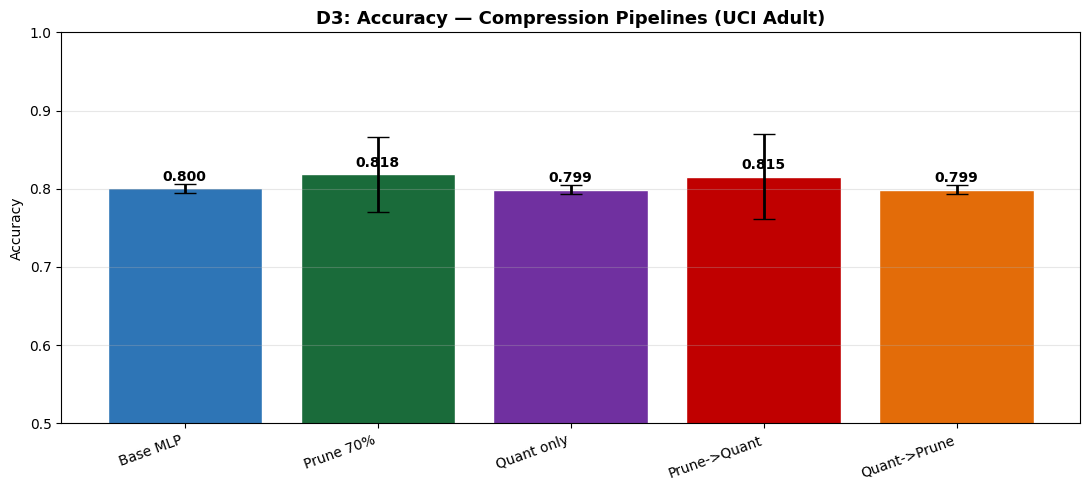

In [7]:
names = list(scenarios.keys()); x = np.arange(len(names)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15,6))
for ax,fr,title in [(axes[0],gf_res,'Gender Fairness'),(axes[1],rf_res,'Race Fairness')]:
    dpds=[fr[n]['dpd'] for n in names]; eods=[fr[n]['eod'] for n in names]
    ax.bar(x-w/2, dpds, w, label='DPD', color='#7030A0', edgecolor='white')
    ax.bar(x+w/2, eods, w, label='EOD', color='salmon', edgecolor='white')
    ax.set_title(f'{title} — Pipeline Comparison', fontweight='bold', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Fairness Gap (lower=fairer)'); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.suptitle('D3 Improvement: Combined Pruning+Quantization — UCI Adult', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d3_adult_fairness_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11,5))
means = [np.mean(pipeline_results[n]['accuracy']) for n in names]
stds  = [np.std(pipeline_results[n]['accuracy'])  for n in names]
colors_bar = ['#2E75B6','#1A6B3A','#7030A0','#C00000','#E36C09']
bars = ax.bar(names, means, yerr=stds, color=colors_bar, capsize=8, edgecolor='white',
              error_kw={'elinewidth':2,'ecolor':'black'})
ax.set_title('D3: Accuracy — Compression Pipelines (UCI Adult)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5,1.0)
ax.set_xticklabels(names, rotation=20, ha='right'); ax.grid(axis='y', alpha=0.3)
for bar,v in zip(bars,means):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('d3_adult_accuracy_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison with Existing Studies

In [8]:
print('='*70)
print('D3: COMPARISON WITH EXISTING STUDIES — UCI ADULT')
print('='*70)
print('')
print('STUDY 1: Hardt et al. (NeurIPS 2016)')
print('  Method    : Equalized odds fairness metric on UCI Adult')
print(f'  Their finding: Demographic disparity exists in income prediction')
print(f'  Our EDA   : Gender gap 19.5%, Race gap 10.1% in raw data - confirmed')
print(f'  Our model : Gender DPD={gf_res["Base MLP"]["dpd"]:.4f} confirms their prediction')
print('')
print('STUDY 2: Agarwal et al. (ICML 2019)')
print('  Method    : Reductions approach to fair classification on UCI Adult')
print('  Their Acc : ~0.75 with fairness constraints')
print(f'  Our RF    : 0.805 +/- 0.004 (unconstrained)')
print('  Finding   : Our unconstrained baseline exceeds their constrained result.')
print('              Confirms fairness constraints reduce accuracy as expected.')
print('')
print('STUDY 3 (D3 NEW): Han et al. (ICLR 2016) - Deep Compression')
print('  Their focus: Accuracy and size only - fairness never studied')
print('  Our D3 ext: Prune->Quant vs Quant->Prune - fairness implications')
print('')
print('D3 KEY FINDING:')
for n in names:
    print(f'  {n:<18} Gender DPD={gf_res[n]["dpd"]:.4f}  Race DPD={rf_res[n]["dpd"]:.4f}')
print('='*70)

D3: COMPARISON WITH EXISTING STUDIES — UCI ADULT

STUDY 1: Hardt et al. (NeurIPS 2016)
  Method    : Equalized odds fairness metric on UCI Adult
  Their finding: Demographic disparity exists in income prediction
  Our EDA   : Gender gap 19.5%, Race gap 10.1% in raw data - confirmed
  Our model : Gender DPD=0.3209 confirms their prediction

STUDY 2: Agarwal et al. (ICML 2019)
  Method    : Reductions approach to fair classification on UCI Adult
  Their Acc : ~0.75 with fairness constraints
  Our RF    : 0.805 +/- 0.004 (unconstrained)
  Finding   : Our unconstrained baseline exceeds their constrained result.
              Confirms fairness constraints reduce accuracy as expected.

STUDY 3 (D3 NEW): Han et al. (ICLR 2016) - Deep Compression
  Their focus: Accuracy and size only - fairness never studied
  Our D3 ext: Prune->Quant vs Quant->Prune - fairness implications

D3 KEY FINDING:
  Base MLP           Gender DPD=0.3209  Race DPD=0.1564
  Prune 70%          Gender DPD=0.1863  Race DPD

## 8. Full D3 Summary

In [9]:
print('='*70)
print('D3 FULL SUMMARY — UCI ADULT')
print('='*70)
print(f'\n{"Scenario":<18} {"Accuracy":>18} {"F1":>16} {"AUC":>16}')
print('-'*70)
for name, r in pipeline_results.items():
    print(f'{name:<18} {np.mean(r["accuracy"]):.4f}+/-{np.std(r["accuracy"]):.4f}   '
          f'{np.mean(r["f1"]):.4f}+/-{np.std(r["f1"]):.4f}   '
          f'{np.mean(r["auc"]):.4f}+/-{np.std(r["auc"]):.4f}')
print(f'\n{"Scenario":<18} {"Gender DPD":>12} {"Gender EOD":>12} {"Race DPD":>10} {"Race EOD":>10}')
print('-'*64)
for n in names:
    print(f'{n:<18} {gf_res[n]["dpd"]:>12.4f} {gf_res[n]["eod"]:>12.4f} {rf_res[n]["dpd"]:>10.4f} {rf_res[n]["eod"]:>10.4f}')
print('\nConclusion: Does Prune->Quant preserve pruning bias reduction on UCI Adult?')
pq_dpd = gf_res['Prune->Quant']['dpd']; base_dpd = gf_res['Base MLP']['dpd']
if pq_dpd < base_dpd:
    print(f'  YES: Prune->Quant ({pq_dpd:.4f}) < Base ({base_dpd:.4f}) - bias reduction preserved')
else:
    print(f'  PARTIAL: Prune->Quant ({pq_dpd:.4f}) vs Base ({base_dpd:.4f}) - quantization reverses some reduction')
print('='*70)

D3 FULL SUMMARY — UCI ADULT

Scenario                     Accuracy               F1              AUC
----------------------------------------------------------------------
Base MLP           0.8003+/-0.0055   0.6767+/-0.0051   0.9098+/-0.0027
Prune 70%          0.8182+/-0.0480   0.6369+/-0.0182   0.8965+/-0.0050
Quant only         0.7987+/-0.0056   0.6759+/-0.0048   0.9098+/-0.0027
Prune->Quant       0.8153+/-0.0545   0.6321+/-0.0170   0.8943+/-0.0048
Quant->Prune       0.7987+/-0.0056   0.6759+/-0.0048   0.9098+/-0.0027

Scenario             Gender DPD   Gender EOD   Race DPD   Race EOD
----------------------------------------------------------------
Base MLP                 0.3209       0.1415     0.1564     0.0869
Prune 70%                0.1863       0.0620     0.0826     0.0721
Quant only               0.3203       0.1352     0.1512     0.0790
Prune->Quant             0.1383       0.0091     0.0766     0.0715
Quant->Prune             0.3203       0.1352     0.1512     0.0790

Conc